In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pickle
import random
import numpy as np
from tqdm import tqdm
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [ ]:

import pickle
with open('/content/drive/MyDrive/video_features_256.pkl', 'rb') as f:
    video_256 = pickle.load(f)
with open('/content/drive/MyDrive/video_features_768.pkl', 'rb') as f:
    video_768 = pickle.load(f)

with open('/content/drive/MyDrive/audio_feat_hubert_origin.pkl', 'rb') as f:
    audio_256 = pickle.load(f)
with open('/content/drive/MyDrive/audio_feat_hubert_aug.pkl', 'rb') as f:
    audio_256_aug = pickle.load(f)
with open('/content/drive/MyDrive/audio_hubert_768.pkl', 'rb') as f:
    audio_768 = pickle.load(f)


text_256 = torch.load('/content/drive/MyDrive/text_features_256(basic+earlystop).pkl',  map_location='cpu')
text_768 = torch.load('/content/drive/MyDrive/text_features_768(basic+earlystop).pkl',  map_location='cpu')
text_256_aug = torch.load('/content/drive/MyDrive/text_features_256(basic+earlystop).pkl',  map_location='cpu')
text_768_aug = torch.load('/content/drive/MyDrive/text_features_768(basic+earlystop).pkl',  map_location='cpu')

y_all=text_256['labels']

In [ ]:
# 조합 1
X_video=video_256['features']
X_audio=audio_256['audio_feat']
X_text=text_256['features']

In [ ]:
# 조합 2
X_video=video_256['features']
X_audio=audio_256['audio_feat']
X_text=text_256_aug['features']

In [ ]:
# 조합 3
X_video=video_768['features']
X_audio=audio_768['audio_feat']
X_text=text_768['features']

In [ ]:
# 조합 4
X_video=video_768['features']
X_audio=audio_768['audio_feat']
X_text=text_768_aug['features']

In [ ]:
# 조합 5
X_video=video_256['features']
X_audio=audio_256_aug['audio_feat']
X_text=text_256_aug['features']

In [ ]:
# 조합 6
X_video=video_256['features']
X_audio=audio_256_aug['audio_feat']
X_text=text_256['features']

In [ ]:
print(X_video.shape)
print(X_audio.shape)
print(X_text.shape)

torch.Size([2199, 768])
torch.Size([2199, 768])
torch.Size([2199, 768])


In [ ]:
X_video = F.normalize(X_video, dim=-1).detach()
X_audio = F.normalize(X_audio, dim=-1).detach()
X_text = F.normalize(X_text, dim=-1).detach()

In [ ]:
class MultiModalDataset(Dataset):
    def __init__(self, video_features, audio_features, text_features, labels):
        self.video_features = video_features
        self.audio_features = audio_features
        self.text_features = text_features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        video = self.video_features[idx]
        audio = self.audio_features[idx]
        text = self.text_features[idx]
        label = self.labels[idx]
        return video, audio, text, label

# --- Train / Val / Test   분리 ---
idx = np.arange(len(y_all))
idx_tr, idx_temp = train_test_split(idx, test_size=0.3, random_state=42, stratify=y_all)
idx_te, idx_val = train_test_split(idx_temp, test_size=0.5, random_state=42, stratify=y_all[idx_temp])

train_set = MultiModalDataset(X_video[idx_tr], X_audio[idx_tr], X_text[idx_tr], y_all[idx_tr])
val_set   = MultiModalDataset(X_video[idx_val], X_audio[idx_val], X_text[idx_val], y_all[idx_val])
test_set  = MultiModalDataset(X_video[idx_te], X_audio[idx_te], X_text[idx_te], y_all[idx_te])

BATCH_SIZE = 16
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_set)}/ Val: {len(val_set)} / Test: {len(test_set)}")
v, a, t, lab = next(iter(train_loader))
print(f"video {tuple(v.shape)}  audio {tuple(a.shape)}  text {tuple(t.shape)}")

Train: 1539/ Val: 330 / Test: 330
video (16, 768)  audio (16, 768)  text (16, 768)


In [ ]:
class GraphMiddleFusionModel(nn.Module):
    # GCN 기반 멀티모달 융합
    def __init__(self, input_dim=768,shared_dim=256, num_gnn_layers=1, num_classes=2,  adjacency=None):
        super().__init__()
        self.input_dim = input_dim
        # --- 1) 차원 통일 ---
        self.video_proj = nn.Linear(input_dim, shared_dim)
        self.audio_proj = nn.Linear(input_dim, shared_dim)
        self.text_proj  = nn.Linear(input_dim, shared_dim)

        # --- 2) 인접 행렬 (3×3) - 행별 정규화 후 buffer 등록 ---
        if adjacency is not None:
            A = torch.tensor(adjacency, dtype=torch.float32)
        else:
            A = torch.ones(3,3)
        self.register_buffer("A", A/A.sum(dim=1, keepdim=True))

        # --- 3) 메시지 패싱 레이어 (각 layer = 학습 가능한 W) ---
        self.gnn_layers = nn.ModuleList([
            nn.Linear(shared_dim, shared_dim) for _ in range(num_gnn_layers)
        ])

        # --- 4) 분류기 ---
        self.classifier = nn.Sequential(
            nn.Linear(shared_dim* 3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, v, a, t):
        # 1) 차원 통일
        if self.input_dim == 768:
            v = F.relu(self.video_proj(v))
            a = F.relu(self.audio_proj(a))
            t = F.relu(self.text_proj(t))

        # 2) 노드 행렬 H: (B, 3, shared_dim)
        H = torch.stack([v,a,t], dim=1)

        # 3) 메시지 패싱 N번 — H' = ReLU(A · layer(H))
        for layer in self.gnn_layers:
            H = F.relu(self.A @ layer(H))

        # 4) 노드 표현을 펼쳐서 분류
        return self.classifier(H.flatten(1))

In [ ]:
class mlp(nn.Module):
    def __init__(self, input_dim=768, shared_dim=256,  hidden_dim=128, num_classes=2):
        super().__init__()
        self.proj =nn.Linear(input_dim, shared_dim)
        self.classifier = nn.Sequential(
            nn.Linear(shared_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        if input_dim==768:
          x= self.proj(x)
        x= self.classifier(x)
        return x

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [ ]:
def train_test_modal(model, train_loader, val_loader, test_loader, num_epochs=20, lr=1e-3, label=""):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adagrad(model.parameters(), lr=lr,)
    early_stopping = EarlyStopping(patience=2, min_delta=0.001)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "test_acc": [],"test_loss":[], "all_pred":[], "all_y":[]}
    best_val_acc = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for v, a, t, yb in train_loader:
            if label=='video':
                m=v
            if label=='audio':
                m=a
            if label=='text':
                m=t
            m, yb = m.to(device),  yb.to(device)
            out = model(m)
            loss = criterion(out, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * yb.size(0)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += yb.size(0)
        train_loss = total_loss / total
        train_acc  = correct / total * 100

        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for v, a, t, yb in val_loader:
                if label=='video':
                    m=v
                if label=='audio':
                    m=a
                if label=='text':
                    m=t
                m, yb = m.to(device),  yb.to(device)
                out = model(m)
                loss = criterion(out, yb)
                total_loss += loss.item() * yb.size(0)
                correct += (out.argmax(1) == yb).sum().item()
                total   += yb.size(0)
        val_loss = total_loss / total
        val_acc = correct / total * 100

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"[{label}] Epoch {epoch+1:2d}  Train Loss: {train_loss:.4f} | TrainAcc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | ValAcc: {val_acc:.2f}%")

        model.eval()
        total_loss, correct, total = 0, 0, 0
        preds=[]; labels=[]
        with torch.no_grad():
            for v, a, t, yb in test_loader:

                if label=='video':
                    m=v
                if label=='audio':
                    m=a
                if label=='text':
                    m=t
                m, yb = m.to(device),  yb.to(device)

                out = model(m)
                pred=out.argmax(dim=1)
                labels.extend(yb.cpu().numpy())
                preds.extend(pred.cpu().numpy())
                loss = criterion(out, yb)
                total_loss += loss.item() * yb.size(0)
                correct += (out.argmax(1) == yb).sum().item()
                total   += yb.size(0)
        test_loss = total_loss / total
        test_acc = correct / total * 100

        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if val_acc > best_val_acc:
            best_val_acc=val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            history["best_epoch"] = epoch+1

        early_stopping(val_loss)

        if early_stopping.early_stop:
          print("Early stopping")
          break

    return history

In [ ]:
def train_test_fusion(model, train_loader, val_loader, test_loader, num_epochs=20, lr=1e-3, label=""):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adagrad(model.parameters(), lr=lr,)
    early_stopping = EarlyStopping(patience=5, min_delta=0.001)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "test_acc": [],"test_loss":[],"train_f1":[],"val_f1":[],"test_f1": [],"all_pred":[], "all_y":[]}
    best_val_acc=0
    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        preds=[]; labels=[]
        for v, a, t, yb in train_loader:
            v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
            out = model(v, a, t)
            pred=out.argmax(dim=1)
            labels.extend(yb.cpu().numpy())
            preds.extend(pred.cpu().numpy())

            loss = criterion(out, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * yb.size(0)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += yb.size(0)
        train_loss = total_loss / total
        train_acc  = correct / total * 100
        train_f1=f1_score(labels, preds, zero_division=0)
        history["train_f1"].append(train_f1)


        model.eval()
        total_loss, correct, total = 0, 0, 0
        preds=[]; labels=[]
        with torch.no_grad():
            for v, a, t, yb in val_loader:
                v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
                out = model(v, a, t)
                pred=out.argmax(dim=1)
                labels.extend(yb.cpu().numpy())
                preds.extend(pred.cpu().numpy())
                loss = criterion(out, yb)
                total_loss += loss.item() * yb.size(0)
                correct += (out.argmax(1) == yb).sum().item()
                total   += yb.size(0)
        val_loss = total_loss / total
        val_acc = correct / total * 100
        val_f1=f1_score(labels, preds, zero_division=0)
        history["val_f1"].append(val_f1)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"[{label}] Epoch {epoch+1:2d}  Train Loss: {train_loss:.4f} | TrainAcc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | ValAcc: {val_acc:.2f}%")

        # test

        model.eval()
        total_loss, correct, total = 0, 0, 0
        preds=[]; labels=[]

        with torch.no_grad():
            for v,a,t, yb in test_loader:
              v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
              out = model(v, a, t)
              pred=out.argmax(dim=1)
              labels.extend(yb.cpu().numpy())
              preds.extend(pred.cpu().numpy())
              loss = criterion(out, yb)
              total_loss += loss.item() * yb.size(0)
              correct += (out.argmax(1) == yb).sum().item()
              total   += yb.size(0)

        test_loss = total_loss / total
        test_acc = correct / total * 100
        test_f1=f1_score(labels, preds, zero_division=0)
        history["test_f1"].append(test_f1)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)


        if val_acc >= best_val_acc:
            best_val_acc=val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            history["best_epoch"] = epoch+1

        early_stopping(val_loss)

        if early_stopping.early_stop:
          print("Early stopping")
          break
    # test
    model.load_state_dict(best_model_weights)
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds=[]; labels=[]

    with torch.no_grad():
      for v,a,t, yb in test_loader:
        v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
        out = model(v, a, t)
        pred=out.argmax(dim=1)
        labels.extend(yb.cpu().numpy())
        preds.extend(pred.cpu().numpy())
        loss = criterion(out, yb)
        total_loss += loss.item() * yb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total   += yb.size(0)
        pred = out.argmax(dim=1)
        history["all_y"].append(yb.cpu())
        history["all_pred"].append(pred.cpu())
    all_y= torch.cat(history["all_y"]).numpy()
    all_pred = torch.cat(history["all_pred"]).numpy()
    test_loss = total_loss / total
    test_acc = correct / total * 100

    print(f"\n[{label}] TestLoss: {test_loss:.4f} | TestAcc: {test_acc:.2f}%")



    return history

In [ ]:
assign_results = {}

In [ ]:
input_dim=X_video.shape[1]
video_model=mlp(input_dim=input_dim).to(device)
history=train_test_modal(video_model, train_loader, val_loader, test_loader, num_epochs=20, lr=1e-3, label="video")
assign_results['video']=history

[video] Epoch  1  Train Loss: 0.6897 | TrainAcc: 55.36% | Val Loss: 0.6872 | ValAcc: 58.79%
[video] Epoch  2  Train Loss: 0.6808 | TrainAcc: 59.06% | Val Loss: 0.6809 | ValAcc: 60.30%
[video] Epoch  3  Train Loss: 0.6702 | TrainAcc: 61.86% | Val Loss: 0.6718 | ValAcc: 62.12%
[video] Epoch  4  Train Loss: 0.6583 | TrainAcc: 63.74% | Val Loss: 0.6623 | ValAcc: 61.82%
[video] Epoch  5  Train Loss: 0.6490 | TrainAcc: 65.63% | Val Loss: 0.6555 | ValAcc: 63.64%
[video] Epoch  6  Train Loss: 0.6402 | TrainAcc: 65.50% | Val Loss: 0.6493 | ValAcc: 64.24%
[video] Epoch  7  Train Loss: 0.6326 | TrainAcc: 65.43% | Val Loss: 0.6499 | ValAcc: 63.33%
[video] Epoch  8  Train Loss: 0.6249 | TrainAcc: 65.63% | Val Loss: 0.6411 | ValAcc: 63.64%
[video] Epoch  9  Train Loss: 0.6194 | TrainAcc: 66.21% | Val Loss: 0.6446 | ValAcc: 62.73%
[video] Epoch 10  Train Loss: 0.6154 | TrainAcc: 66.86% | Val Loss: 0.6437 | ValAcc: 62.73%
Early stopping


In [ ]:
input_dim=X_video.shape[1]
audio_model=mlp(input_dim=input_dim).to(device)
history=train_test_modal(audio_model, train_loader, val_loader, test_loader, num_epochs=20, lr=1e-3, label="audio")
assign_results['audio']=history

[audio] Epoch  1  Train Loss: 0.6929 | TrainAcc: 51.53% | Val Loss: 0.6907 | ValAcc: 59.09%
[audio] Epoch  2  Train Loss: 0.6895 | TrainAcc: 56.53% | Val Loss: 0.6882 | ValAcc: 58.18%
[audio] Epoch  3  Train Loss: 0.6864 | TrainAcc: 59.45% | Val Loss: 0.6855 | ValAcc: 58.79%
[audio] Epoch  4  Train Loss: 0.6819 | TrainAcc: 61.92% | Val Loss: 0.6822 | ValAcc: 61.21%
[audio] Epoch  5  Train Loss: 0.6770 | TrainAcc: 62.05% | Val Loss: 0.6777 | ValAcc: 63.03%
[audio] Epoch  6  Train Loss: 0.6708 | TrainAcc: 63.48% | Val Loss: 0.6734 | ValAcc: 62.42%
[audio] Epoch  7  Train Loss: 0.6658 | TrainAcc: 64.20% | Val Loss: 0.6692 | ValAcc: 62.42%
[audio] Epoch  8  Train Loss: 0.6593 | TrainAcc: 66.21% | Val Loss: 0.6654 | ValAcc: 65.15%
[audio] Epoch  9  Train Loss: 0.6542 | TrainAcc: 65.04% | Val Loss: 0.6607 | ValAcc: 61.82%
[audio] Epoch 10  Train Loss: 0.6482 | TrainAcc: 64.85% | Val Loss: 0.6570 | ValAcc: 63.03%
[audio] Epoch 11  Train Loss: 0.6423 | TrainAcc: 66.02% | Val Loss: 0.6527 | Val

In [ ]:
input_dim=X_video.shape[1]
text_model=mlp(input_dim=input_dim).to(device)
history=train_test_modal(text_model, train_loader, val_loader, test_loader, num_epochs=20, lr=1e-3, label="text")
assign_results['text']=history

[text] Epoch  1  Train Loss: 0.2883 | TrainAcc: 93.05% | Val Loss: 0.2827 | ValAcc: 90.00%
[text] Epoch  2  Train Loss: 0.2236 | TrainAcc: 93.57% | Val Loss: 0.2826 | ValAcc: 90.00%
[text] Epoch  3  Train Loss: 0.2213 | TrainAcc: 93.44% | Val Loss: 0.2822 | ValAcc: 90.61%
Early stopping


In [ ]:
NUM_EPOCHS  = 40
LR          = 1e-3
input_dim  = X_video.shape[1]
NUM_GNN     = 1
A = [
    [1, 1, 1], # V
    [1, 1, 1], # A
    [1, 1, 1], # T
]
run_name='full connect'

model_1 =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model_1, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.3283 | TrainAcc: 90.45% | Val Loss: 0.2867 | ValAcc: 90.91%
[GCN] Epoch  2  Train Loss: 0.2224 | TrainAcc: 93.50% | Val Loss: 0.2806 | ValAcc: 90.61%
[GCN] Epoch  3  Train Loss: 0.2137 | TrainAcc: 93.57% | Val Loss: 0.2792 | ValAcc: 90.91%
[GCN] Epoch  4  Train Loss: 0.2129 | TrainAcc: 93.50% | Val Loss: 0.2726 | ValAcc: 90.91%
[GCN] Epoch  5  Train Loss: 0.2073 | TrainAcc: 93.50% | Val Loss: 0.2740 | ValAcc: 90.91%
[GCN] Epoch  6  Train Loss: 0.2083 | TrainAcc: 93.63% | Val Loss: 0.2758 | ValAcc: 90.91%
[GCN] Epoch  7  Train Loss: 0.2057 | TrainAcc: 93.57% | Val Loss: 0.2676 | ValAcc: 90.91%
[GCN] Epoch  8  Train Loss: 0.2041 | TrainAcc: 93.57% | Val Loss: 0.2675 | ValAcc: 91.21%
[GCN] Epoch  9  Train Loss: 0.1994 | TrainAcc: 93.70% | Val Loss: 0.2658 | ValAcc: 91.21%
[GCN] Epoch 10  Train Loss: 0.2030 | TrainAcc: 93.63% | Val Loss: 0.2641 | ValAcc: 91.21%
[GCN] Epoch 11  Train Loss: 0.1974 | TrainAcc: 93.83% | Val Loss: 0.2641 | ValAcc: 91.52%
[GCN] Epoc

In [ ]:
A = [
    [1, 0, 0], # V
    [0, 1, 0], # A
    [0, 0, 1], # T
]
run_name='self connect'

model_2 =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model_2, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.3166 | TrainAcc: 91.29% | Val Loss: 0.2887 | ValAcc: 90.30%
[GCN] Epoch  2  Train Loss: 0.2253 | TrainAcc: 93.44% | Val Loss: 0.2835 | ValAcc: 90.30%
[GCN] Epoch  3  Train Loss: 0.2202 | TrainAcc: 93.37% | Val Loss: 0.2838 | ValAcc: 90.30%
[GCN] Epoch  4  Train Loss: 0.2166 | TrainAcc: 93.37% | Val Loss: 0.2746 | ValAcc: 90.91%
[GCN] Epoch  5  Train Loss: 0.2169 | TrainAcc: 93.31% | Val Loss: 0.2759 | ValAcc: 90.91%
[GCN] Epoch  6  Train Loss: 0.2122 | TrainAcc: 93.44% | Val Loss: 0.2733 | ValAcc: 90.91%
[GCN] Epoch  7  Train Loss: 0.2133 | TrainAcc: 93.50% | Val Loss: 0.2688 | ValAcc: 90.61%
[GCN] Epoch  8  Train Loss: 0.2137 | TrainAcc: 93.37% | Val Loss: 0.2703 | ValAcc: 90.61%
[GCN] Epoch  9  Train Loss: 0.2067 | TrainAcc: 93.31% | Val Loss: 0.2724 | ValAcc: 90.91%
[GCN] Epoch 10  Train Loss: 0.2148 | TrainAcc: 93.50% | Val Loss: 0.2680 | ValAcc: 90.61%
[GCN] Epoch 11  Train Loss: 0.2077 | TrainAcc: 93.50% | Val Loss: 0.2698 | ValAcc: 90.61%
[GCN] Epoc

In [ ]:
A = [
    [1, 0, 1], # V
    [0, 1, 1], # A
    [0, 0, 1], # T
]
run_name='self connect + v,a->t'

model_3 =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model_3, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.3060 | TrainAcc: 92.20% | Val Loss: 0.2925 | ValAcc: 90.00%
[GCN] Epoch  2  Train Loss: 0.2275 | TrainAcc: 93.57% | Val Loss: 0.2795 | ValAcc: 90.00%
[GCN] Epoch  3  Train Loss: 0.2202 | TrainAcc: 93.50% | Val Loss: 0.2786 | ValAcc: 90.00%
[GCN] Epoch  4  Train Loss: 0.2164 | TrainAcc: 93.63% | Val Loss: 0.2784 | ValAcc: 90.00%
[GCN] Epoch  5  Train Loss: 0.2169 | TrainAcc: 93.57% | Val Loss: 0.2718 | ValAcc: 90.91%
[GCN] Epoch  6  Train Loss: 0.2139 | TrainAcc: 93.63% | Val Loss: 0.2709 | ValAcc: 90.91%
[GCN] Epoch  7  Train Loss: 0.2125 | TrainAcc: 93.31% | Val Loss: 0.2694 | ValAcc: 90.91%
[GCN] Epoch  8  Train Loss: 0.2116 | TrainAcc: 93.57% | Val Loss: 0.2702 | ValAcc: 91.21%
[GCN] Epoch  9  Train Loss: 0.2111 | TrainAcc: 93.63% | Val Loss: 0.2683 | ValAcc: 91.21%
[GCN] Epoch 10  Train Loss: 0.2102 | TrainAcc: 93.63% | Val Loss: 0.2690 | ValAcc: 91.21%
[GCN] Epoch 11  Train Loss: 0.2085 | TrainAcc: 93.63% | Val Loss: 0.2709 | ValAcc: 90.91%
[GCN] Epoc

In [ ]:
A = [
    [1, 1, 0], # V
    [1, 1, 0], # A
    [0, 0, 1], # T
]
run_name='self connect + v<->a'
model_4 =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model_4, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.3218 | TrainAcc: 91.49% | Val Loss: 0.2806 | ValAcc: 90.91%
[GCN] Epoch  2  Train Loss: 0.2213 | TrainAcc: 93.44% | Val Loss: 0.2820 | ValAcc: 90.91%
[GCN] Epoch  3  Train Loss: 0.2216 | TrainAcc: 93.44% | Val Loss: 0.2827 | ValAcc: 90.61%
[GCN] Epoch  4  Train Loss: 0.2216 | TrainAcc: 93.31% | Val Loss: 0.2770 | ValAcc: 90.91%
[GCN] Epoch  5  Train Loss: 0.2190 | TrainAcc: 93.24% | Val Loss: 0.2728 | ValAcc: 90.91%
[GCN] Epoch  6  Train Loss: 0.2164 | TrainAcc: 93.37% | Val Loss: 0.2703 | ValAcc: 90.61%
[GCN] Epoch  7  Train Loss: 0.2151 | TrainAcc: 93.31% | Val Loss: 0.2711 | ValAcc: 90.61%
[GCN] Epoch  8  Train Loss: 0.2143 | TrainAcc: 93.37% | Val Loss: 0.2714 | ValAcc: 90.61%
[GCN] Epoch  9  Train Loss: 0.2155 | TrainAcc: 93.44% | Val Loss: 0.2706 | ValAcc: 90.30%
[GCN] Epoch 10  Train Loss: 0.2101 | TrainAcc: 93.44% | Val Loss: 0.2686 | ValAcc: 90.61%
[GCN] Epoch 11  Train Loss: 0.2110 | TrainAcc: 93.24% | Val Loss: 0.2744 | ValAcc: 90.61%
[GCN] Epoc

In [ ]:
A = [
    [1, 0, 0], # V
    [0, 1, 0], # A
    [1, 1, 1], # T
]
run_name='self connect + t->v,a'
model_5 =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model_5, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.3883 | TrainAcc: 87.26% | Val Loss: 0.2888 | ValAcc: 90.00%
[GCN] Epoch  2  Train Loss: 0.2254 | TrainAcc: 93.44% | Val Loss: 0.2866 | ValAcc: 90.30%
[GCN] Epoch  3  Train Loss: 0.2223 | TrainAcc: 93.63% | Val Loss: 0.2847 | ValAcc: 90.30%
[GCN] Epoch  4  Train Loss: 0.2171 | TrainAcc: 93.50% | Val Loss: 0.2805 | ValAcc: 90.61%
[GCN] Epoch  5  Train Loss: 0.2196 | TrainAcc: 93.44% | Val Loss: 0.2750 | ValAcc: 90.91%
[GCN] Epoch  6  Train Loss: 0.2153 | TrainAcc: 93.57% | Val Loss: 0.2720 | ValAcc: 90.91%
[GCN] Epoch  7  Train Loss: 0.2130 | TrainAcc: 93.63% | Val Loss: 0.2789 | ValAcc: 90.91%
[GCN] Epoch  8  Train Loss: 0.2093 | TrainAcc: 93.44% | Val Loss: 0.2710 | ValAcc: 90.91%
[GCN] Epoch  9  Train Loss: 0.2094 | TrainAcc: 93.50% | Val Loss: 0.2723 | ValAcc: 91.21%
[GCN] Epoch 10  Train Loss: 0.2055 | TrainAcc: 93.76% | Val Loss: 0.2672 | ValAcc: 90.91%
[GCN] Epoch 11  Train Loss: 0.2023 | TrainAcc: 93.63% | Val Loss: 0.2739 | ValAcc: 90.91%
[GCN] Epoc

In [ ]:
A = [
    [1, 1, 1], # V
    [1, 1, 1], # A
    [0, 0, 1], # T
]
run_name='self connect + v<->a + v,a->t'
model_6 =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model_6, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=1e-3, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.3078 | TrainAcc: 92.27% | Val Loss: 0.2917 | ValAcc: 90.00%
[GCN] Epoch  2  Train Loss: 0.2248 | TrainAcc: 93.57% | Val Loss: 0.2838 | ValAcc: 90.00%
[GCN] Epoch  3  Train Loss: 0.2186 | TrainAcc: 93.57% | Val Loss: 0.2792 | ValAcc: 90.61%
[GCN] Epoch  4  Train Loss: 0.2155 | TrainAcc: 93.57% | Val Loss: 0.2752 | ValAcc: 90.91%
[GCN] Epoch  5  Train Loss: 0.2127 | TrainAcc: 93.63% | Val Loss: 0.2720 | ValAcc: 90.91%
[GCN] Epoch  6  Train Loss: 0.2107 | TrainAcc: 93.37% | Val Loss: 0.2729 | ValAcc: 91.21%
[GCN] Epoch  7  Train Loss: 0.2109 | TrainAcc: 93.76% | Val Loss: 0.2706 | ValAcc: 91.21%
[GCN] Epoch  8  Train Loss: 0.2091 | TrainAcc: 93.83% | Val Loss: 0.2690 | ValAcc: 91.21%
[GCN] Epoch  9  Train Loss: 0.2071 | TrainAcc: 93.63% | Val Loss: 0.2658 | ValAcc: 91.52%
[GCN] Epoch 10  Train Loss: 0.2071 | TrainAcc: 93.83% | Val Loss: 0.2654 | ValAcc: 91.21%
[GCN] Epoch 11  Train Loss: 0.2049 | TrainAcc: 93.70% | Val Loss: 0.2641 | ValAcc: 91.52%
[GCN] Epoc

/tmp/ipykernel_3542/1556291064.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8); ax.grid(alpha=0.3)


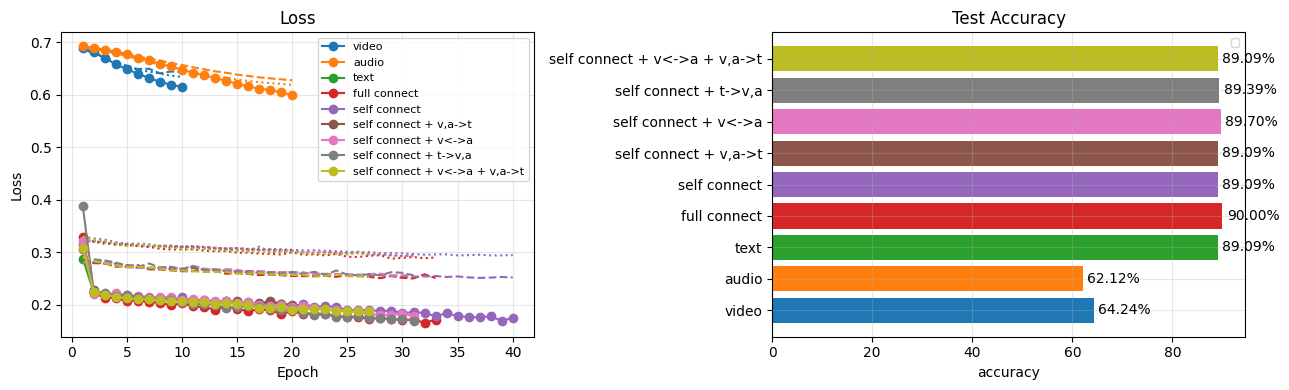


[self connect + v<->a + v,a->t] 최종 Test Acc: 89.09%
누적된 실험 (9개): ['video', 'audio', 'text', 'full connect', 'self connect', 'self connect + v,a->t', 'self connect + v<->a', 'self connect + t->v,a', 'self connect + v<->a + v,a->t']


In [ ]:

fig_a, ax_a = plt.subplots(1, 2, figsize=(13, 4))
plt.close(fig_a)
from IPython.display import display

for ax in ax_a:
    ax.clear()
for name, h in assign_results.items():
    ep = range(1, len(h["train_loss"]) + 1)
    best_epoch=h['best_epoch']
    line=ax_a[0].plot(ep, h["train_loss"], "-o", label=name)[0]
    ax_a[0].plot(ep, h['val_loss'],"--", color=line.get_color())
    ax_a[0].plot(ep,h['test_loss'], linestyle=":", color=line.get_color())
    bar=ax_a[1].barh(y=name, width=h['test_acc'][best_epoch-1])
    ax_a[1].bar_label( bar,  fmt="%.2f%%",  padding=3)


for ax in ax_a:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax_a[0].set_title("Loss"); ax_a[0].set_xlabel("Epoch"); ax_a[0].set_ylabel("Loss")
ax_a[1].set_title("Test Accuracy"); ax_a[1].set_xlabel("accuracy")
fig_a.tight_layout()
display(fig_a)

print(f"\n[{run_name}] 최종 Test Acc: {history['test_acc'][best_epoch-1]:.2f}%")
print(f"누적된 실험 ({len(assign_results)}개): {list(assign_results.keys())}")

# 베스트 모델

In [ ]:
best_connect=  'full connect'
b_hist=assign_results[best_connect]

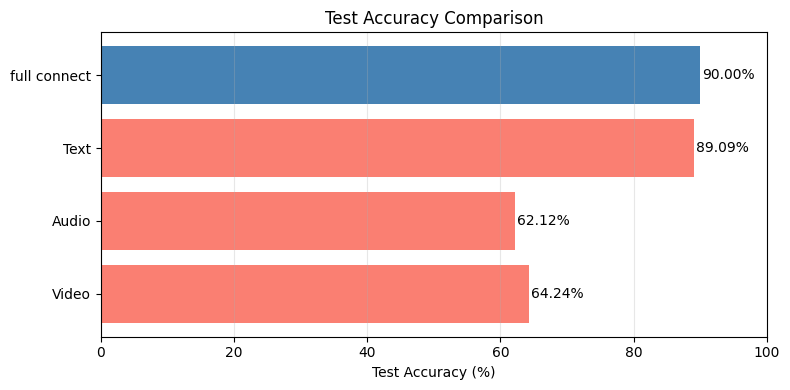

In [ ]:
v_h=assign_results['video']
a_h=assign_results['audio']
t_h=assign_results['text']
video_acc=v_h['test_acc'][v_h['best_epoch']-1]
audio_acc=a_h['test_acc'][a_h['best_epoch']-1]
text_acc=t_h['test_acc'][t_h['best_epoch']-1]
gcn_acc=b_hist['test_acc'][b_hist['best_epoch']-1]
models = ['Video', 'Audio', 'Text', best_connect]
accs   = [video_acc, audio_acc, text_acc, gcn_acc]

# GCN만 파란색, 나머지는 빨간색
colors = ['#fa7f72', '#fa7f72', '#fa7f72', '#4682b4']

plt.figure(figsize=(8, 4))

bars = plt.barh(models, accs, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,

        f'{width:.2f}%',
        va='center'
    )

plt.xlabel('Test Accuracy (%)')
plt.title('Test Accuracy Comparison')
plt.xlim(0, max(accs) + 10)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

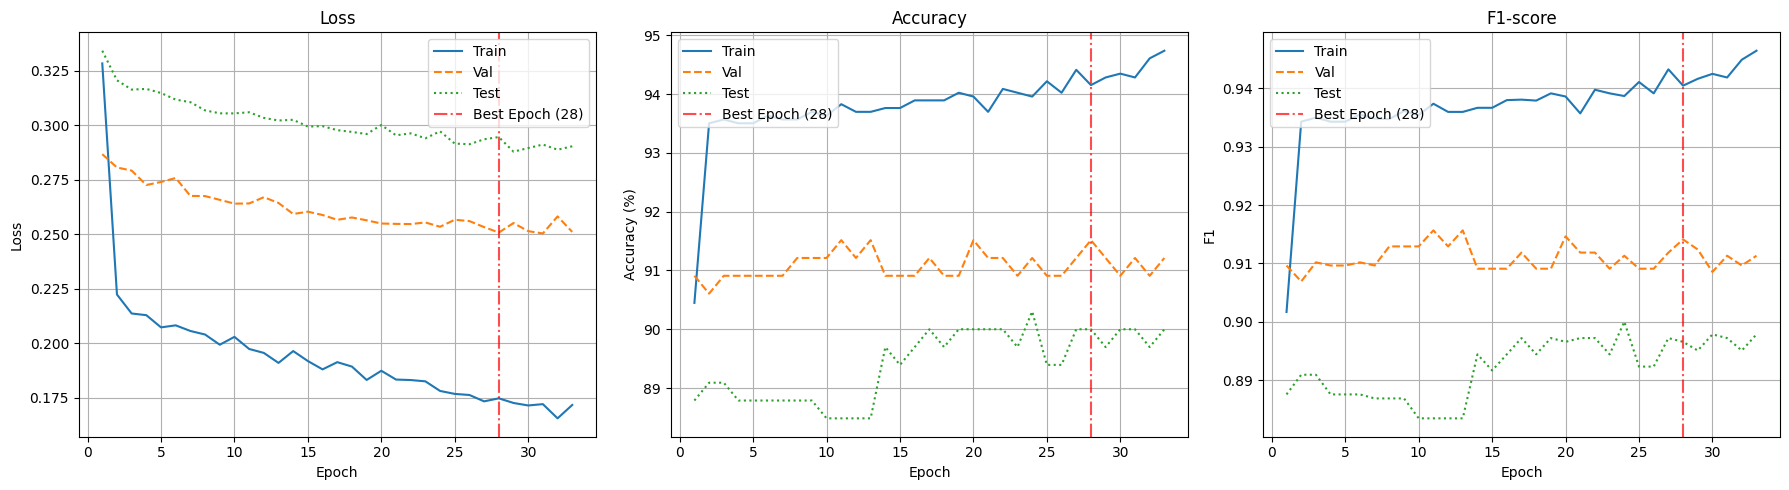

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(b_hist["train_loss"]) + 1)

# --------------------
# 1. Loss
# --------------------
axes[0].plot(epochs, b_hist["train_loss"], '-', label='Train')
axes[0].plot(epochs, b_hist["val_loss"], '--', label='Val')
axes[0].plot(epochs, b_hist["test_loss"], ':', label='Test')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].axvline(
    b_hist['best_epoch'],
    color='red',
    linestyle='-.',
    alpha=0.7,
    label=f'Best Epoch ({b_hist["best_epoch"]})'
)
axes[0].legend()
axes[0].grid(True)

# --------------------
# 2. Accuracy
# --------------------
axes[1].plot(epochs, b_hist["train_acc"], '-', label='Train')
axes[1].plot(epochs, b_hist["val_acc"], '--', label='Val')
axes[1].plot(epochs,b_hist["test_acc"],linestyle=":",label='Test')

axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].axvline(
    b_hist['best_epoch'],
    color='red',
    linestyle='-.',
    alpha=0.7,
    label=f'Best Epoch ({b_hist["best_epoch"]})'
)
axes[1].legend(loc='upper left')
axes[1].grid(True)

# --------------------
# 3. F1-score
# --------------------
axes[2].plot(epochs, b_hist["train_f1"], '-', label='Train')
axes[2].plot(epochs, b_hist["val_f1"], '--', label='Val')
axes[2].plot(epochs,b_hist["test_f1"],linestyle="dotted", label="Test")

axes[2].set_title("F1-score")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1")
axes[2].axvline(
    b_hist['best_epoch'],
    color='red',
    linestyle='-.',
    alpha=0.7,
    label=f'Best Epoch ({b_hist["best_epoch"]})'
)
axes[2].legend(loc='upper left')
axes[2].grid(True)

plt.tight_layout()
plt.show()

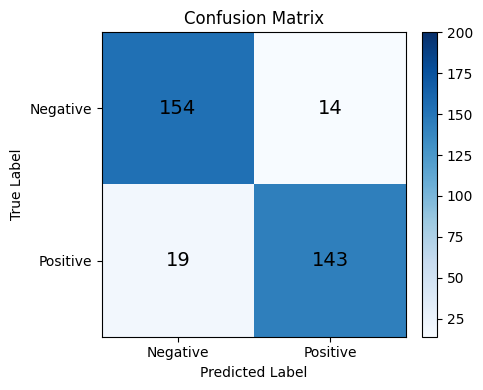

TN: 154  | Negative를 Negative로 맞춤
FP: 14  | Negative인데 Positive로 잘못 예측 → 오탐
FN: 19  | Positive인데 Negative로 잘못 예측 → 미탐
TP: 143  | Positive를 Positive로 맞춤


In [ ]:
y_true = torch.cat(b_hist['all_y']).cpu().numpy()
y_pred = torch.cat(b_hist['all_pred']).cpu().numpy()
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(cm, cmap="Blues", vmax=200)

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Negative", "Positive"])
ax.set_yticklabels(["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(f"TN: {tn}  | Negative를 Negative로 맞춤")
print(f"FP: {fp}  | Negative인데 Positive로 잘못 예측 → 오탐")
print(f"FN: {fn}  | Positive인데 Negative로 잘못 예측 → 미탐")
print(f"TP: {tp}  | Positive를 Positive로 맞춤")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)
from sklearn.metrics import classification_report

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred,zero_division=0)
rec  = recall_score(y_true, y_pred,zero_division=0)
f1   = f1_score(y_true, y_pred,zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
kappa = cohen_kappa_score(y_true, y_pred)

print(f"[Graph: {best_connect}]")
print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-score   : {f1:.4f}")
print(f"Kappa      : {kappa:.4f}")
print()

print("[2] 상세 성능 성적표 (Classification Report)")
print("="*60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        digits=2,
        zero_division=0
    )
)
##

[Graph: full connect]
Accuracy   : 0.9000
Precision  : 0.9108
Recall     : 0.8827
Specificity: 0.9167
F1-score   : 0.8966
Kappa      : 0.7998

[2] 상세 성능 성적표 (Classification Report)
              precision    recall  f1-score   support

    Negative       0.89      0.92      0.90       168
    Positive       0.91      0.88      0.90       162

    accuracy                           0.90       330
   macro avg       0.90      0.90      0.90       330
weighted avg       0.90      0.90      0.90       330

